# TOG Attacks on YOLOv3 (Darknet53) — PyTorch

Self-contained PyTorch reimplementation (no Keras / no `thirdparty` imports).
- Model / detect: `yolov3_model.py`
- TOG losses / gradients: `loss_extractor.py`
- Attacks: `tog_attacks.py`
- Helpers: `utils.py`


## Preparation of Victim Detector


In [ ]:
from pathlib import Path

from PIL import Image

from eval import evaluate_coco_map
from tog_model import YOLOv3TOGModel
from tog_attacks import (
    tog_fabrication,
    tog_mislabeling,
    tog_untargeted,
    tog_vanishing,
)
from utils import letterbox_image, visualize_detections
from yolov3_model import YOLOv3Detector

ROOT = Path('.').resolve()


/home/khointn/anaconda3/envs/od_attacks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load the detector from local Darknet weights (`weights/yolov3.weights`).


In [2]:
weights = ROOT / 'weights' / 'yolov3.weights'
detector = YOLOv3Detector(weights=weights)
victim = YOLOv3TOGModel(detector)
print('device:', detector.device)
print('num classes:', detector.num_classes)

device: cuda
num classes: 80


## Clean COCO evaluation

In [ ]:
coco_root = ROOT / 'data' / 'coco'

# Set max_images=None to evaluate the full val2017 split (5000 images).
benign_metrics = evaluate_coco_map(
    detector,
    coco_root=coco_root,
    split='val2017',
    max_images=100,
    confidence_threshold=0.001,
)
print(benign_metrics)

## Configuration of Attack Hyperparameters


In [3]:
epsilon = 8 / 255.       # Maximum L-infinity perturbation
step_size = 2 / 255.     # Per-iteration update size
num_iterations = 10      # Number of attack iterations


Load and visualize the image to be attacked.


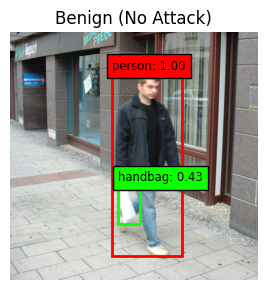

detections: 2


In [5]:
image_path = ROOT / 'assets' / 'example_2.png'

input_img = Image.open(image_path).convert('RGB')
x_query, x_meta = letterbox_image(input_img, size=detector.model_image_size)
detections_query = detector.detect(x_query, confidence_threshold=detector.confidence_threshold)
visualize_detections({
    'Benign (No Attack)': (x_query, detections_query, detector.model_image_size, detector.class_names)
})
print('detections:', len(detections_query))


## TOG-untargeted Attack

Random untargeted attacks fool the victim detector to randomly misdetect without targeting any specific object.


In [10]:
# TODO: Run the TOG

"""
1. Call the tog_untargeted and pass the necessary params
2. Detect the adversarial image
3. Use visualize_detections to visualize
"""

'\n1. Call the tog_untargeted and pass the necessary params\n2. Detect the adversarial image\n3. Use visualize_detections to visualize\n'

## TOG-vanishing Attack

TOG-vanishing aims at removing the victim's ability to identify objects (false negatives).


In [11]:
# TODO: Run the TOG

"""
1. Call the tog_vanishing and pass the necessary params
2. Detect the adversarial image
3. Use visualize_detections to visualize
"""

'\n1. Call the tog_vanishing and pass the necessary params\n2. Detect the adversarial image\n3. Use visualize_detections to visualize\n'

## TOG-fabrication Attack

TOG-fabrication fabricates additional detections (false positives).


In [12]:
# TODO: Run the TOG

"""
1. Call the tog_fabrication and pass the necessary params
2. Detect the adversarial image
3. Use visualize_detections to visualize
"""


'\n1. Call the tog_fabrication and pass the necessary params\n2. Detect the adversarial image\n3. Use visualize_detections to visualize\n'

## TOG-mislabeling Attack

Most-likely (ML) and least-likely (LL) class mislabeling attacks.


In [1]:
# TODO: Run the TOG

"""
1. Call the tog_mislabeling and pass the necessary params, with 2 option most likely and least likely
2. Detect the adversarial image
3. Use visualize_detections to visualize
"""

'\n1. Call the tog_mislabeling and pass the necessary params, with 2 option most likely and least likely\n2. Detect the adversarial image\n3. Use visualize_detections to visualize\n'